Original data shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Eigenvalues (explained variance):
[2.9381 0.9202 0.1477 0.0209]

Explained variance ratio per component:
PC1: 0.7296  (72.96%)
PC2: 0.2285  (22.85%)
PC3: 0.0367  (3.67%)
PC4: 0.0052  (0.52%)

Cumulative explained variance: [0.7296 0.9581 0.9948 1.    ]

Reduced data shape: (150, 2)
Variance retained by 2 components: 95.81%

Component loadings:
                     PC1    PC2
sepal length (cm)  0.521  0.377
sepal width (cm)  -0.269  0.923
petal length (cm)  0.580  0.024
petal width (cm)   0.565  0.067

First 5 samples after PCA:
      PC1     PC2
0 -2.2647  0.4800
1 -2.0810 -0.6741
2 -2.3642 -0.3419
3 -2.2994 -0.5974
4 -2.3898  0.6468


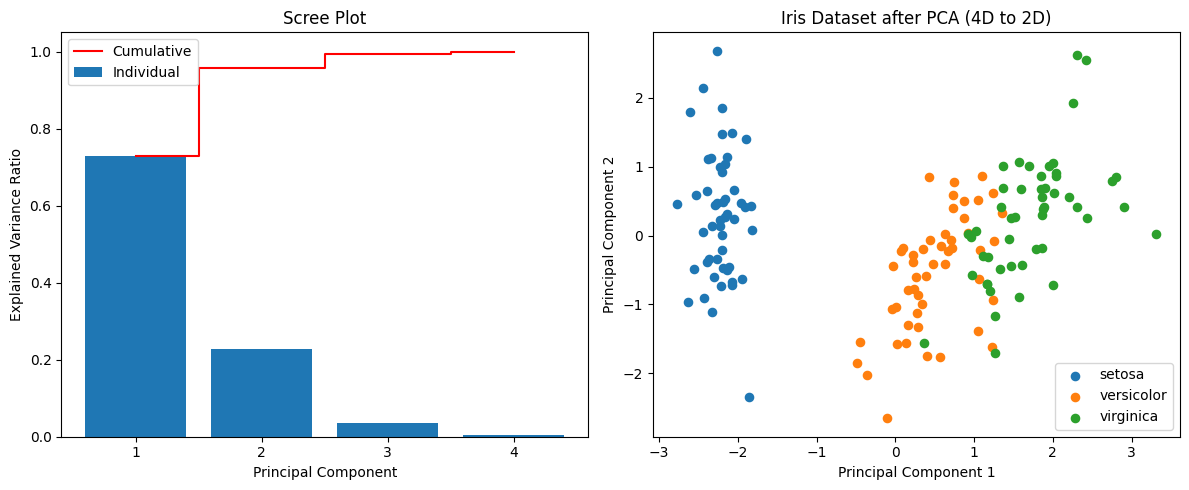

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
X = iris.data
y = iris.target
features = iris.feature_names
print("Original data shape:", X.shape)
print("Features:", features)

X_scaled = StandardScaler().fit_transform(X)

pca_full = PCA(n_components=4)
pca_full.fit(X_scaled)
ratio = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ratio)

print("\nEigenvalues (explained variance):")
print(np.round(pca_full.explained_variance_, 4))
print("\nExplained variance ratio per component:")
for i, r in enumerate(ratio, 1):
    print(f"PC{i}: {r:.4f}  ({r * 100:.2f}%)")
print("\nCumulative explained variance:", np.round(cumulative, 4))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("\nReduced data shape:", X_pca.shape)
print("Variance retained by 2 components: "
      f"{pca.explained_variance_ratio_.sum() * 100:.2f}%")

loadings = pd.DataFrame(pca.components_.T, index=features,
                        columns=['PC1', 'PC2'])
print("\nComponent loadings:")
print(loadings.round(3))

print("\nFirst 5 samples after PCA:")
print(pd.DataFrame(X_pca[:5], columns=['PC1', 'PC2']).round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].bar(range(1, 5), ratio, label='Individual')
ax[0].step(range(1, 5), cumulative, where='mid', color='red',
           label='Cumulative')
ax[0].set_xlabel("Principal Component")
ax[0].set_ylabel("Explained Variance Ratio")
ax[0].set_title("Scree Plot")
ax[0].set_xticks(range(1, 5))
ax[0].legend()

for i, name in enumerate(iris.target_names):
    ax[1].scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=name, s=35)
ax[1].set_xlabel("Principal Component 1")
ax[1].set_ylabel("Principal Component 2")
ax[1].set_title("Iris Dataset after PCA (4D to 2D)")
ax[1].legend()
plt.tight_layout()
plt.show()
